###### 132_7_practical_daily_work_fill_answer.ipynb

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
plt.rcParams["font.family"] = "Meiryo"
plt.rcParams["axes.unicode_minus"] = False

In [7]:
df = pd.read_csv(
    "dataset/daily_work_minutes_practice.csv",
)

df

,work_date,task_type,work_minutes,comment
0,2022-01-01,集計,45,日次集計
1,2022-01-01,確認,30,内容確認
2,2022-01-02,資料作成,60,会議資料
3,2022-01-04,集計,90,空白あり
4,2022-01-05,確認,未入力,数値NG
5,2022-01-07,会議,120,週次会議
6,2022/01/07,議事録,40,日付表記違い
7,2022-01-09,集計,75,日次集計
8,NG_DATE,確認,30,日付NG
9,2022-01-10,資料作成,abc,数値NG


In [9]:
df["work_date_row"] = df["work_date"]
df.head()

,work_date,task_type,work_minutes,comment,work_date_row
0,2022-01-01,集計,45,日次集計,2022-01-01
1,2022-01-01,確認,30,内容確認,2022-01-01
2,2022-01-02,資料作成,60,会議資料,2022-01-02
3,2022-01-04,集計,90,空白あり,2022-01-04
4,2022-01-05,確認,未入力,数値NG,2022-01-05


In [12]:
df["work_date_clean"] = (
    df["work_date"]
    .astype("string")
    .str.strip()
)
df.head()

,work_date,task_type,work_minutes,comment,work_date_row,work_date_clean
0,2022-01-01,集計,45,日次集計,2022-01-01,2022-01-01
1,2022-01-01,確認,30,内容確認,2022-01-01,2022-01-01
2,2022-01-02,資料作成,60,会議資料,2022-01-02,2022-01-02
3,2022-01-04,集計,90,空白あり,2022-01-04,2022-01-04
4,2022-01-05,確認,未入力,数値NG,2022-01-05,2022-01-05


In [13]:
df["work_date_dt"] = pd.to_datetime(
    df["work_date_clean"],
    errors="coerce",
    format="mixed",
 )
df

,work_date,task_type,work_minutes,comment,work_date_row,work_date_clean,work_date_dt
0,2022-01-01,集計,45,日次集計,2022-01-01,2022-01-01,2022-01-01
1,2022-01-01,確認,30,内容確認,2022-01-01,2022-01-01,2022-01-01
2,2022-01-02,資料作成,60,会議資料,2022-01-02,2022-01-02,2022-01-02
3,2022-01-04,集計,90,空白あり,2022-01-04,2022-01-04,2022-01-04
4,2022-01-05,確認,未入力,数値NG,2022-01-05,2022-01-05,2022-01-05
5,2022-01-07,会議,120,週次会議,2022-01-07,2022-01-07,2022-01-07
6,2022/01/07,議事録,40,日付表記違い,2022/01/07,2022/01/07,2022-01-07
7,2022-01-09,集計,75,日次集計,2022-01-09,2022-01-09,2022-01-09
8,NG_DATE,確認,30,日付NG,NG_DATE,NG_DATE,NaT
9,2022-01-10,資料作成,abc,数値NG,2022-01-10,2022-01-10,2022-01-10


In [16]:
df["work_date_dt"].dtype

dtype('<M8[ns]')

In [20]:
df["work_minutes"].dtype

df["work_minutes_num"] = pd.to_numeric(
    df["work_minutes"],
    errors="coerce",
)
df.dtypes

work_date                   object
task_type                   object
work_minutes                object
comment                     object
work_date_row               object
work_date_clean     string[python]
work_date_dt        datetime64[ns]
work_minutes_num           float64
dtype: object

In [21]:
df_date_ng = df[
    df["work_date_dt"].isna()
].copy()

df_date_ng

,work_date,task_type,work_minutes,comment,work_date_row,work_date_clean,work_date_dt,work_minutes_num
8,NG_DATE,確認,30,日付NG,NG_DATE,NG_DATE,NaT,30.0


In [22]:
df_minutes_ng = df[
    df["work_minutes_num"].isna()
].copy()

df_minutes_ng

,work_date,task_type,work_minutes,comment,work_date_row,work_date_clean,work_date_dt,work_minutes_num
4,2022-01-05,確認,未入力,数値NG,2022-01-05,2022-01-05,2022-01-05,NaN
9,2022-01-10,資料作成,abc,数値NG,2022-01-10,2022-01-10,2022-01-10,NaN


In [23]:
df_work = df[
    df["work_date_dt"].notna()
    & df["work_minutes_num"].notna()
].copy()

df_work

,work_date,task_type,work_minutes,comment,work_date_row,work_date_clean,work_date_dt,work_minutes_num
0,2022-01-01,集計,45,日次集計,2022-01-01,2022-01-01,2022-01-01,45.0
1,2022-01-01,確認,30,内容確認,2022-01-01,2022-01-01,2022-01-01,30.0
2,2022-01-02,資料作成,60,会議資料,2022-01-02,2022-01-02,2022-01-02,60.0
3,2022-01-04,集計,90,空白あり,2022-01-04,2022-01-04,2022-01-04,90.0
5,2022-01-07,会議,120,週次会議,2022-01-07,2022-01-07,2022-01-07,120.0
6,2022/01/07,議事録,40,日付表記違い,2022/01/07,2022/01/07,2022-01-07,40.0
7,2022-01-09,集計,75,日次集計,2022-01-09,2022-01-09,2022-01-09,75.0
10,2022-01-10,確認,35,内容確認,2022-01-10,2022-01-10,2022-01-10,35.0


In [29]:
df_work["work_date_day"] = df_work["work_date_dt"].dt.normalize()
df_work

,work_date,task_type,work_minutes,comment,work_date_row,work_date_clean,work_date_dt,work_minutes_num,work_date_day
0,2022-01-01,集計,45,日次集計,2022-01-01,2022-01-01,2022-01-01,45.0,2022-01-01
1,2022-01-01,確認,30,内容確認,2022-01-01,2022-01-01,2022-01-01,30.0,2022-01-01
2,2022-01-02,資料作成,60,会議資料,2022-01-02,2022-01-02,2022-01-02,60.0,2022-01-02
3,2022-01-04,集計,90,空白あり,2022-01-04,2022-01-04,2022-01-04,90.0,2022-01-04
5,2022-01-07,会議,120,週次会議,2022-01-07,2022-01-07,2022-01-07,120.0,2022-01-07
6,2022/01/07,議事録,40,日付表記違い,2022/01/07,2022/01/07,2022-01-07,40.0,2022-01-07
7,2022-01-09,集計,75,日次集計,2022-01-09,2022-01-09,2022-01-09,75.0,2022-01-09
10,2022-01-10,確認,35,内容確認,2022-01-10,2022-01-10,2022-01-10,35.0,2022-01-10


In [30]:
df_work["work_date_day"]

0    2022-01-01
1    2022-01-01
2    2022-01-02
3    2022-01-04
5    2022-01-07
6    2022-01-07
7    2022-01-09
10   2022-01-10
Name: work_date_day, dtype: datetime64[ns]

In [31]:
df_daily = (
    df_work
    .groupby("work_date_day")
    .agg(
        work_minutes_sum=("work_minutes_num", "sum"),
        record_count=("work_minutes_num", "count"),
    )
)
df_daily

,work_minutes_sum,record_count
work_date_day,,
2022-01-01,75.0,2
2022-01-02,60.0,1
2022-01-04,90.0,1
2022-01-07,160.0,2
2022-01-09,75.0,1
2022-01-10,35.0,1


In [32]:
date_index = pd.date_range(
    start=df_daily.index.min(),
    end=df_daily.index.max(),
    freq="D",
)
date_index

DatetimeIndex(['2022-01-01', '2022-01-02', '2022-01-03', '2022-01-04',
               '2022-01-05', '2022-01-06', '2022-01-07', '2022-01-08',
               '2022-01-09', '2022-01-10'],
              dtype='datetime64[ns]', freq='D')

In [34]:
filled_df = df_daily.reindex(
    date_index,
    fill_value=0,
)
filled_df

,work_minutes_sum,record_count
2022-01-01,75.0,2
2022-01-02,60.0,1
2022-01-03,0.0,0
2022-01-04,90.0,1
2022-01-05,0.0,0
2022-01-06,0.0,0
2022-01-07,160.0,2
2022-01-08,0.0,0
2022-01-09,75.0,1
2022-01-10,35.0,1


In [35]:
filled_df.index.name = "work_date"
filled_df

,work_minutes_sum,record_count
work_date,,
2022-01-01,75.0,2
2022-01-02,60.0,1
2022-01-03,0.0,0
2022-01-04,90.0,1
2022-01-05,0.0,0
2022-01-06,0.0,0
2022-01-07,160.0,2
2022-01-08,0.0,0
2022-01-09,75.0,1


In [49]:
filled_df["cumulative_minutes"] = filled_df["work_minutes_sum"].cumsum()
filled_df

,work_minutes_sum,record_count,comulative_minutes,cumulative_minutes
work_date,,,,
2022-01-01,75.0,2,75.0,75.0
2022-01-02,60.0,1,135.0,135.0
2022-01-03,0.0,0,135.0,135.0
2022-01-04,90.0,1,225.0,225.0
2022-01-05,0.0,0,225.0,225.0
2022-01-06,0.0,0,225.0,225.0
2022-01-07,160.0,2,385.0,385.0
2022-01-08,0.0,0,385.0,385.0
2022-01-09,75.0,1,460.0,460.0


In [50]:
plt.figure(figsize=(10, 4))

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

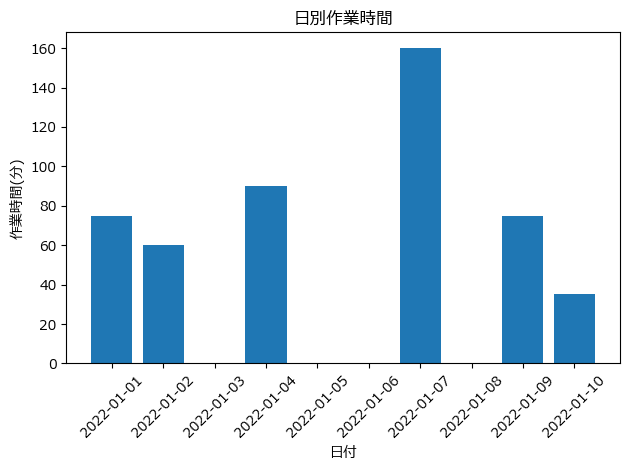

In [51]:
plt.bar(
    filled_df.index.astype(str),
    filled_df["work_minutes_sum"],
)

plt.title("日別作業時間")
plt.xlabel("日付")
plt.ylabel("作業時間(分)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [46]:
plt.figure(figsize=(10, 4))

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

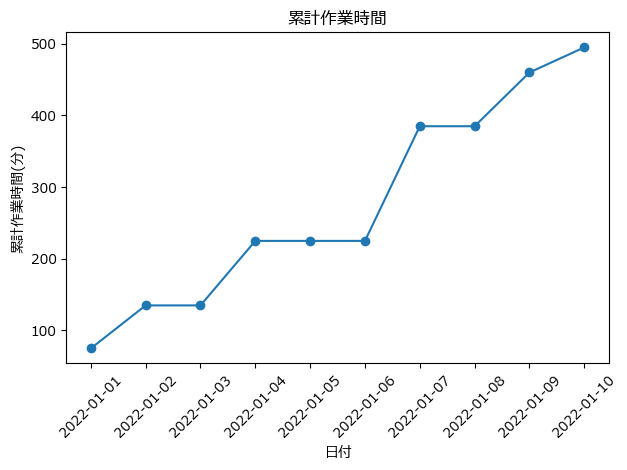

In [56]:
plt.plot(
    filled_df.index.astype(str),
    filled_df["cumulative_minutes"],
    marker="o",
)

plt.title("累計作業時間")
plt.xlabel("日付")
plt.ylabel("累計作業時間(分)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()